LLMs who cant give the structures output, we need use output parsers

### Output Parsers
Output Parsers in LangChain helps convert raw LLM response into structured formats like JSON, CSV, Pydantic models and more, They ensure consistency, validation and ease of use in application

### 4 main output parsers
1. string output parser
2. json output parser
3. Structures Output parser
4. Pydantic output parser

# String Output Parser
The StrOutputParser is the simplest output parser in langchain. It is used to parse the output of a language model(LLM) and return it as a plain string

In [4]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv  
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
import os

load_dotenv()  # Load environment variables from .env file

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

# Pass llm into ChatHuggingFace
model = ChatHuggingFace(llm=llm)

template1 = PromptTemplate(
    template = 'Write a detailed report on topic {topic}',
    input_variables = ['topic']
)

template2 = PromptTemplate(
    template = 'Write a 5 line summary on the following text. /n {text}',
    input_variables = ['text']
)

prompt1 = template1.invoke({
    "topic": "The impact of AI on society"
})

result = model.invoke(prompt1)
print(result.content)

prompt2 = template2.invoke({
    "text": result.content
})

result1 = model.invoke(prompt2)

print(result1.content)


**The Impact of Artificial Intelligence (AI) on Society: A Comprehensive Report**

**Executive Summary**

Artificial Intelligence (AI) has revolutionized various aspects of modern society, transforming the way we live, work, and interact. The impact of AI on society is multifaceted and far-reaching, bringing about both positive and negative effects. This report provides an in-depth analysis of the impact of AI on society, covering its benefits, challenges, and potential risks.

**Introduction**

AI refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as learning, problem-solving, and decision-making. The rapid advancement of AI technologies, fueled by advances in machine learning, natural language processing, and robotics, has led to widespread adoption across various industries and sectors. From healthcare and finance to transportation and education, AI is transforming the way we live and work.

**Positive Impacts o

### Above was without stroutputparser
## below we will use stoutputparser

In [5]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv  
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os

load_dotenv()  # Load environment variables from .env file

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

# Pass llm into ChatHuggingFace
model = ChatHuggingFace(llm=llm)

template1 = PromptTemplate(
    template = 'Write a detailed report on topic {topic}',
    input_variables = ['topic']
)

template2 = PromptTemplate(
    template = 'Write a 5 line summary on the following text. /n {text}',
    input_variables = ['text']
)

# prompt1 = template1.invoke({
#     "topic": "The impact of AI on society"
# })

# result = model.invoke(prompt1)
# print(result.content)

# prompt2 = template2.invoke({
#     "text": result.content
# })

# result1 = model.invoke(prompt2)

# print(result1.content)

parser = StrOutputParser()
chain = template1 | model | parser | template2 | model | parser

result = chain.invoke({
    "topic": "Black Hole Physics"
})

print(result)




Here's a 5-line summary of the text:

Black holes are enigmatic objects with such strong gravitational pull that nothing, including light, can escape their region in space. A black hole forms when a massive star collapses, warping the fabric of spacetime around it. There are four types of black holes: stellar, supermassive, intermediate-mass, and primordial, each with distinct properties and origins. Black holes have unique properties such as an event horizon, singularity, ergosphere, and Hawking radiation. Researchers continue to study black hole physics to understand their behavior and effects on the surrounding environment.


# Json Output parser
You can enforce schema in this output parser
 

In [15]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser


load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

parser = JsonOutputParser()

template = PromptTemplate(
    template = 'Give me the name, age, city of a fictional person \n{format_instruction}',
    input_variables = [],
    partial_variables = {'format_instruction': parser.get_format_instructions()}
)

# prompt = template.format()

# # print(prompt)

# result = model.invoke(prompt)
# final_res = parser.parse(result.content)

# instead of above three lines we can use the chain

chain = template | model | parser
final_res = chain.invoke({})
print(final_res)
print(type(final_res))

{'name': 'Emily Wilson', 'age': 28, 'city': 'San Francisco'}
<class 'dict'>


# structured Output Parser
Structured Output Parser is an output parser in Langchain that helps extrazt structuredjson data from LLM responses based on predefined schemas

It works by defining a list of fields (RespiseSchema) that the model should return, enduring the output follows a structures format

You can enforece Schema

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain.output_parsers.structured import StructuredOutputParser, ResponseSchema

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

schema = [
    ResponseSchema(name="name", description="The name of the person"),
    ResponseSchema(name="age", description="The age of the person"),
    ResponseSchema(name="city", description="The city where the person lives")
]

parser = StructuredOutputParser.from_response_schemas(schema)

template = PromptTemplate(
    template = 'Give me 3 facts about the {topic} \n{format_instruction}',
    input_variables = ['topic'],
    partial_variables = {'format_instruction': parser.get_format_instructions()}
)

prompt = template.format(topic="Eiffel Tower")

result = model.invoke(prompt)

final_res =parser.parse(result.content)
print(result.content)

ModuleNotFoundError: No module named 'langchain.output_parsers'

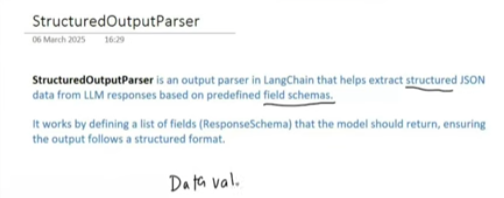

# Pydantic Output Parser

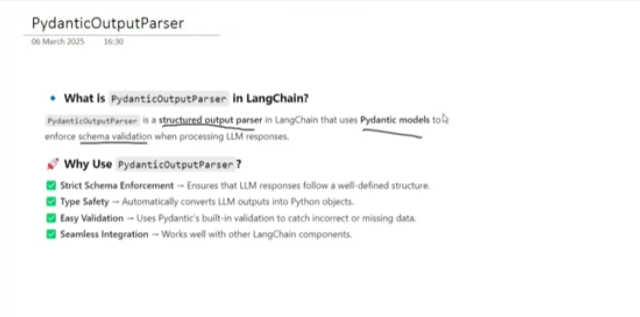

instead of schemma, u use pydantic object and you can do the data validation

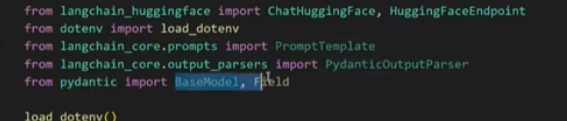

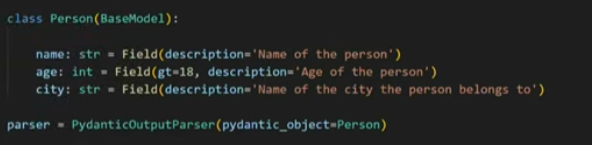

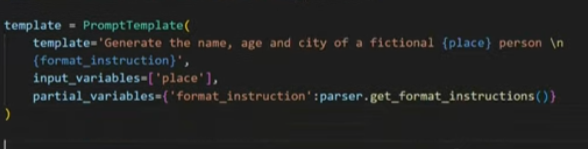

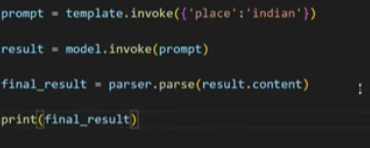